In [1]:
import numpy as np
import pandas as pd
import logging
import pickle
import os 
import matplotlib.pyplot as plt

datadir = "data/oracle_ICMS_150/"

# 5000 patterns. Each pattern consists of indices. 4000 are sampled once, while 1000 are oracle trials (50 patterns sampled 20 times each). These are denoted with pattern_id names 4001 to 4050. 
# Each stimulation is delivered in 600 ms period, with 1400 inter-stimulation interval. Thus, 2 s per stimulation * 5000 stimulations = 10000 seconds total experiment.

# [19, 104, 201, 211, 300, 310, 311, 312] are neuron IDs that may be problematic (>200 Hz firing rate), maybe multi-unit or artifact. 

pattern_registrations = pickle.load(open(os.path.join(datadir, "pattern_registrations.pkl"), "rb"))
# spkVecs contains spike times for all neurons. 47 are recorded.
spikes_df = pd.DataFrame(np.load(os.path.join(datadir, "spkVecs.npy"))) # size = (3396476,))
spikes_df.columns = ['timestamp', 'neuron_id', 'segment_index']
spikes_df.drop(columns=['segment_index'], inplace=True)
spikes_df['timestamp'] = spikes_df['timestamp'].astype(int)
spikes_df['neuron_id'] = spikes_df['neuron_id'].astype(int) # noncontinuous neuron ids from with numbers corresponding to shank location
spikes_df.sort_values(by=['timestamp', 'neuron_id'], inplace=True)
print (spikes_df.shape)
print (spikes_df['neuron_id'].nunique(), " unique neurons recorded")
print (spikes_df['timestamp'].max()/30000, " seconds of recording")
spikes_df.head(5)

# optionally, drop neurons with very high firing rates that may be multi-unit activity or artifacts
problematic_neurons = [19, 104, 201, 211, 300
, 310, 311, 312]
spikes_df = spikes_df[~spikes_df['neuron_id'].isin(problematic_neurons)]
print (spikes_df['neuron_id'].nunique(), " unique neurons recorded after dropping problematic neurons")

(2927375, 2)
71  unique neurons recorded
10255.772266666667  seconds of recording
63  unique neurons recorded after dropping problematic neurons


In [2]:
import pandas as pd
import numpy as np

def read_pattern_json(data):
    # 1. Flatten the Pattern -> Steps level
    # We use record_path to reach the 'steps' and meta to keep parent info
    df = pd.json_normalize(
        data, 
        record_path=['steps'], 
        meta=[
            'pattern_name', # given name of the pattern
            'pattern_lambda', # given lambda parameter that generated the pattern 
            'pattern_flag_start_timestamp', # given starting timpestamp of pattern
            'pattern_timing_index' # given order of pattern from 1-5,000 (first to last)
        ],
        record_prefix='step_'
    )
    # 2. Flatten the 'step_channel_delays' list into individual rows
    # This creates a row for every delay entry. Steps with [] will become NaN.
    df = df.explode('step_channel_delays').reset_index(drop=True)

    # 3. Convert the dictionaries in 'step_channel_delays' into separate columns
    delays_df = pd.json_normalize(df['step_channel_delays'])
    
    # 4. Store pattern length
    df['pattern_idx_length'] = df.groupby('pattern_timing_index')['step_index'].transform('max') + 1

    # 5. Combine and cleanup
    final_df = pd.concat([df.drop(columns=['step_channel_delays']), delays_df], axis=1)
    
    # 6. Convert timestamps to integers and subtract original timestamp from step timestamps
    final_df['step_start_timestamp'] = final_df['step_start_timestamp'].astype(int)
    final_df['pattern_flag_start_timestamp'] = final_df['pattern_flag_start_timestamp'].astype(int)
    
    # 7. Add is_oracle column (True for pattern_name 4001-4050)
    final_df['is_oracle'] = (final_df['pattern_name'] >= 4001) & (final_df['pattern_name'] <= 4050)
    
    # 8. Add trial column
    # For non-oracle patterns: trial = 1 (single trial each)
    # For oracle patterns: trial = 1-10 (10 repeats of each pattern)
    # We assign trial numbers based on the order of appearance (pattern_timing_index)
    final_df['trial'] = 1  # Default for non-oracle
    
    # For oracle patterns, assign trial number based on order of occurrence
    oracle_mask = final_df['is_oracle']
    if oracle_mask.any():
        # Get unique (pattern_name, pattern_timing_index) pairs for oracle patterns
        oracle_occurrences = final_df.loc[oracle_mask, ['pattern_name', 'pattern_timing_index']].drop_duplicates()
        oracle_occurrences = oracle_occurrences.sort_values('pattern_timing_index')
        
        # Assign trial number (1-10) for each pattern_name based on order of appearance
        oracle_occurrences['trial'] = oracle_occurrences.groupby('pattern_name').cumcount() + 1
        
        # Merge back to get trial numbers for oracle patterns
        trial_map = oracle_occurrences.set_index('pattern_timing_index')['trial'].to_dict()
        final_df.loc[oracle_mask, 'trial'] = final_df.loc[oracle_mask, 'pattern_timing_index'].map(trial_map)

    return final_df



In [3]:
pattern_df = read_pattern_json(pattern_registrations)

# define pattern end as pattern's start time - 1
# build unique patterns and set end = next pattern's start - 1
patterns = (pattern_df.groupby(['pattern_timing_index', 'pattern_name'])['pattern_flag_start_timestamp']
            .first().reset_index())
patterns = patterns.sort_values('pattern_timing_index').reset_index(drop=True)

# last spike time for final end
last_spike_time = spikes_df['timestamp'].max()

# end = next start - 1
patterns['pattern_end_timestamp'] = patterns['pattern_flag_start_timestamp'].shift(-1) - 1
patterns['pattern_end_timestamp'].iloc[-1] = last_spike_time

# ensure integer timestamps
patterns['pattern_end_timestamp'] = patterns['pattern_end_timestamp'].astype(int)
patterns['pattern_flag_start_timestamp'] = patterns['pattern_flag_start_timestamp'].astype(int)

# merge end times back into the full step-level dataframe
pattern_df = pattern_df.merge(
    patterns[['pattern_timing_index', 'pattern_end_timestamp']],
    on='pattern_timing_index',
    how='left'
)

# how many times each pattern appears in separate timestamps
pattern_counts = pattern_df[['pattern_name', 'pattern_timing_index']].drop_duplicates().groupby('pattern_name').size()
min_pattern_timestamp = pattern_df['pattern_flag_start_timestamp'].min()

# Center times to 0 for easier intepretation
pattern_df['pattern_flag_start_timestamp'] -= min_pattern_timestamp
pattern_df['pattern_end_timestamp'] -= min_pattern_timestamp
pattern_df['pattern_duration'] = pattern_df['pattern_end_timestamp'] - pattern_df['pattern_flag_start_timestamp']
pattern_df['step_start_timestamp'] -= min_pattern_timestamp

spikes_df['timestamp'] -= min_pattern_timestamp
pattern_df.head(30)

/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_97550/502124743.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  patterns['pattern_end_timestamp'].iloc[-1] = last_spike_time
/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipy

,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_flag_start_timestamp,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial,pattern_end_timestamp,pattern_duration
0,0,2033,4033,1.0,0,0,10,81.0,-1.0,True,1,61751,61751
1,0,2033,4033,1.0,0,0,10,89.0,0.0,True,1,61751,61751
2,1,4064,4033,1.0,0,0,10,7.0,2.0,True,1,61751,61751
3,1,4064,4033,1.0,0,0,10,4.0,0.0,True,1,61751,61751
4,1,4064,4033,1.0,0,0,10,34.0,0.0,True,1,61751,61751
5,2,5964,4033,1.0,0,0,10,3.0,-1.0,True,1,61751,61751
6,2,5964,4033,1.0,0,0,10,4.0,0.0,True,1,61751,61751
7,3,7896,4033,1.0,0,0,10,63.0,-1.0,True,1,61751,61751
8,3,7896,4033,1.0,0,0,10,70.0,0.0,True,1,61751,61751
9,4,9855,4033,1.0,0,0,10,14.0,1.0,True,1,61751,61751


In [4]:
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
print (f"Total unique stimulation channels used: {len(channel_to_index)}")
print ("Stimulation channel names: ", [str(int(k)) for k in sorted(channel_to_index.keys())])
spiking_neurons = spikes_df['neuron_id'].unique()
spiking_neurons.sort()
print (f"Total spiking neurons recorded: {len(spiking_neurons)}")
print ("Spiking neuron names: ", spiking_neurons)
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}


Total unique stimulation channels used: 42
Stimulation channel names:  ['1', '2', '3', '4', '7', '9', '10', '12', '14', '20', '22', '30', '33', '34', '36', '37', '39', '41', '44', '46', '47', '49', '54', '56', '60', '63', '64', '66', '67', '69', '70', '71', '72', '73', '81', '82', '88', '89', '90', '92', '93', '95']
Total spiking neurons recorded: 63
Spiking neuron names:  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  20  21  22  23 100 101 102 103 105 106 107 108 109 110 111 200 202
 203 204 205 206 207 208 209 210 212 213 214 301 302 303 304 305 306 307
 308 309 313 314 315 316 317 318 319]


In [5]:
# # Pattern duration plot
pattern_durations = pattern_df.groupby(['pattern_name']).first()['pattern_duration']
print(pattern_durations[abs(pattern_durations) > 65000].shape[0], " outliers with duration > 65000")
pattern_durations[abs(pattern_durations) > 65000]
print (pattern_df[pattern_df['pattern_name'] == 1236])
# plt.figure(figsize=(10, 6))
# n, bins, patches = plt.hist(pattern_durations, bins=5, color='skyblue', edgecolor='black')

# # Add counts on top of bars
# for i in range(len(n)):
#     plt.text(bins[i] + (bins[i+1] - bins[i]) / 2, n[i], "n=" + str(int(n[i])), ha='center', va='bottom')

# plt.title('Distribution of Pattern Durations')
# plt.xlabel('Duration')
# plt.ylabel('Number of Patterns')
# plt.grid()
# plt.show()
# print(pattern_durations.describe())
# print(pattern_durations[pattern_durations > 65000].shape[0], " outliers with duration > 65000")

0  outliers with duration > 65000
        step_index  step_start_timestamp pattern_name pattern_lambda  \
116564           0             306693788         1236            1.0   
116565           0             306693788         1236            1.0   
116566           1             306696043         1236            1.0   
116567           1             306696043         1236            1.0   
116568           2             306697963         1236            1.0   
116569           2             306697963         1236            1.0   
116570           3             306699872         1236            1.0   
116571           3             306699872         1236            1.0   
116572           3             306699872         1236            1.0   
116573           3             306699872         1236            1.0   
116574           4             306701672         1236            1.0   
116575           5             306703707         1236            1.0   
116576           5            

In [6]:
# Calculate firing rate distribution over patterns per neuron (mean and SD)
seen_patterns = {}
firing_rates = {}
for neuron_id in sorted(spikes_df['neuron_id'].unique()):
    neuron_spikes = spikes_df[spikes_df['neuron_id'] == neuron_id]
    rates = []
    for idx, row in pattern_df.iterrows():
        if row['pattern_name'] in seen_patterns:
            continue # quick and dirty
        t_start = row['pattern_flag_start_timestamp']
        t_end = row['pattern_end_timestamp']
        count = neuron_spikes[(neuron_spikes['timestamp'] >= t_start) & (neuron_spikes['timestamp'] < t_end)].shape[0]
        duration_sec = (t_end - t_start) / 30000  # Convert ticks to seconds
        rate = count / duration_sec if duration_sec > 0 else 0
        rates.append(rate)
        seen_patterns[row['pattern_name']] = True
    firing_rates[neuron_id] = {
        'mean_rate': np.mean(rates),
        'std_rate': np.std(rates)
    }
firing_rates_df = pd.DataFrame.from_dict(firing_rates, orient='index')
firing_rates_df.columns = ['mean_firing_rate', 'std_firing_rate']

# make a violin plot for each neuron of firing rates across patterns
# plt.figure(figsize=(12, 6))
# plt.violinplot([spikes_df[spikes_df['neuron_id'] == nid]['timestamp'].groupby(
#     pd.cut(spikes_df[spikes_df['neuron_id'] == nid]['timestamp'], bins=patterns['pattern_flag_start_timestamp'].tolist() + [last_spike_time])
# ).count() / ((patterns['pattern_end_timestamp'] - patterns['pattern_flag_start_timestamp']).values / 30000) for nid in sorted(spikes_df['neuron_id'].unique())],
#                showmeans=True)
# plt.xticks(ticks=np.arange(1, len(spikes_df['neuron_id'].unique()) + 1), labels=sorted(spikes_df['neuron_id'].unique()) , rotation=90)
# plt.xlabel('Neuron ID')
# plt.ylabel('Firing Rate (spikes/sec)')
# plt.title('Firing Rate Distribution Across Patterns per Neuron')
# plt.tight_layout()
# plt.savefig('patterns_data_firing_rate_distribution_per_neuron.png')
# plt.show()



/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/shubhom/anaconda3/envs/3_11/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [7]:
# Inputs: 600 ms (10 60ms steps) x 44 stimulating channels with 4 delay modes.
# Key by pattern_timing_index to preserve all 10 trials of oracle patterns
pattern_stims = {}  # keyed by pattern_name (stimulus is same for all trials of same pattern)
pattern_polarities = {}  # keyed by pattern_name, tracks polarity (-1 or 1) for each pulse
spike_responses = {}  # keyed by pattern_timing_index (unique per trial)
timing_to_pattern = {}  # map timing_index -> pattern_name for lookups

# Get unique trials (pattern_timing_index, pattern_name pairs)
unique_trials = pattern_df[['pattern_timing_index', 'pattern_name', 'pattern_flag_start_timestamp', 'pattern_end_timestamp', 'is_oracle', 'trial']].drop_duplicates()

for _, trial_info in unique_trials.iterrows():
    timing_idx = trial_info['pattern_timing_index']
    pattern_name = trial_info['pattern_name']
    pattern_start_time = trial_info['pattern_flag_start_timestamp']
    pattern_end_time = trial_info['pattern_end_timestamp']
    
    timing_to_pattern[timing_idx] = pattern_name
    
    # Build stim pattern (same for all trials of same pattern, only compute once)
    if pattern_name not in pattern_stims:
        pattern_subset = pattern_df[pattern_df['pattern_name'] == pattern_name].drop_duplicates(subset=['step_index', 'channel', 'delay_mode'])
        stim = np.zeros((44, 600))  # 44 channels, 600 ms duration
        polarity = np.zeros((44, 600))  # Track polarity: -1 for delay_mode -1, +1 otherwise
        for idx, row in pattern_subset.iterrows():
            step_index = row['step_index']
            stim_ms = 60 * step_index  # each step is 60 ms
            if pd.isna(row['channel']):
                continue  # No stimulation for this step
            channel_index = channel_to_index[int(row['channel'])]
            delay_mode = int(row['delay_mode'])
            # Polarity is -1 for delay_mode -1, +1 otherwise
            pulse_polarity = -1 if delay_mode == -1 else 1
            
            if delay_mode == 0:  # 3 pulses, 50 Hz, starting at stim_ms
                for pulse in range(3):
                    pulse_time = stim_ms + pulse * 20
                    if pulse_time < 600:
                        stim[channel_index, pulse_time] = 3
                        polarity[channel_index, pulse_time] = pulse_polarity
            elif delay_mode == 1:  # 3 pulses, 50 Hz, starting at 10ms after stim_ms
                for pulse in range(3):
                    pulse_time = stim_ms + 10 + pulse * 20
                    if pulse_time < 600:
                        stim[channel_index, pulse_time] = 3
                        polarity[channel_index, pulse_time] = pulse_polarity
            elif delay_mode == -1:  # same as 0 but with reverse phase structure
                for pulse in range(3): 
                    pulse_time = stim_ms + pulse * 20
                    if pulse_time < 600:
                        stim[channel_index, pulse_time] = 3
                        polarity[channel_index, pulse_time] = pulse_polarity
            elif delay_mode == 2:  # 6 pulses, 100 Hz, starting at stim_ms
                for pulse in range(6):
                    pulse_time = stim_ms + pulse * 10
                    if pulse_time < 600:
                        stim[channel_index, pulse_time] = 3
                        polarity[channel_index, pulse_time] = pulse_polarity
        pattern_stims[pattern_name] = stim
        pattern_polarities[pattern_name] = polarity
    
    # Build spike responses for this specific trial (keyed by timing_index)
    spikes_during_pattern = spikes_df[(spikes_df['timestamp'] >= pattern_start_time) & (spikes_df['timestamp'] < pattern_end_time)]
    spike_responses_pattern = np.zeros((len(spiking_neurons), 2000))
    for idx, row in spikes_during_pattern.iterrows():
        neuron_id = row['neuron_id']
        neuron_index = spiking_neuron_to_index[neuron_id]
        spike_time = row['timestamp'] - pattern_start_time
        if 0 <= spike_time < 2000:
            spike_responses_pattern[neuron_index, spike_time] = 1
    spike_responses[timing_idx] = spike_responses_pattern

print(f"Total unique patterns: {len(pattern_stims)}")
print(f"Total trials (spike responses): {len(spike_responses)}")
print(f"Oracle trials: {unique_trials['is_oracle'].sum()}")
print(f"Non-oracle trials: {(~unique_trials['is_oracle')).sum()}")

SyntaxError: f-string: closing parenthesis ')' does not match opening parenthesis '[' (377810375.py, line 75)

Pattern 4033: stim shape (44, 600), polarity shape (44, 600)


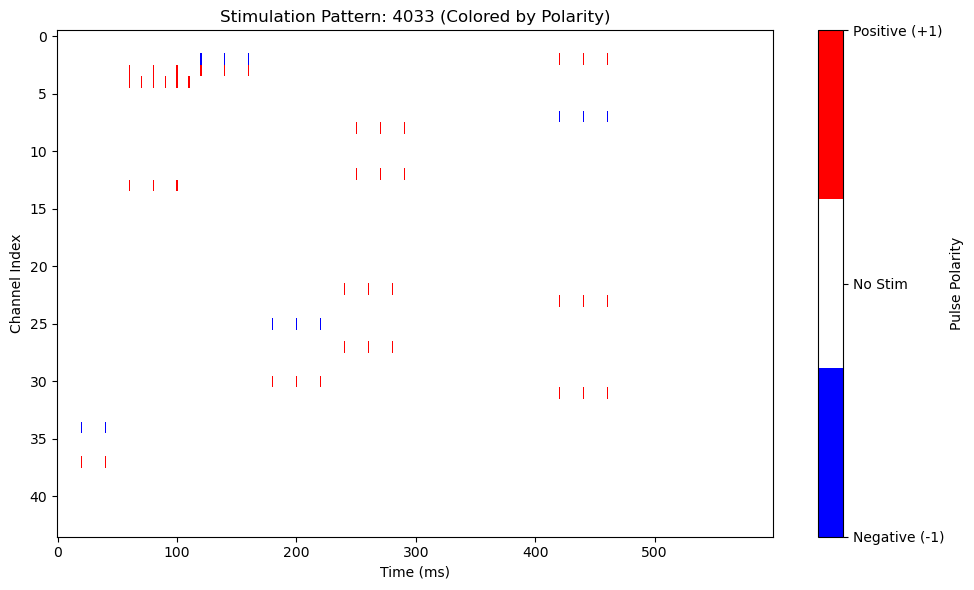

Pattern 4017: stim shape (44, 600), polarity shape (44, 600)


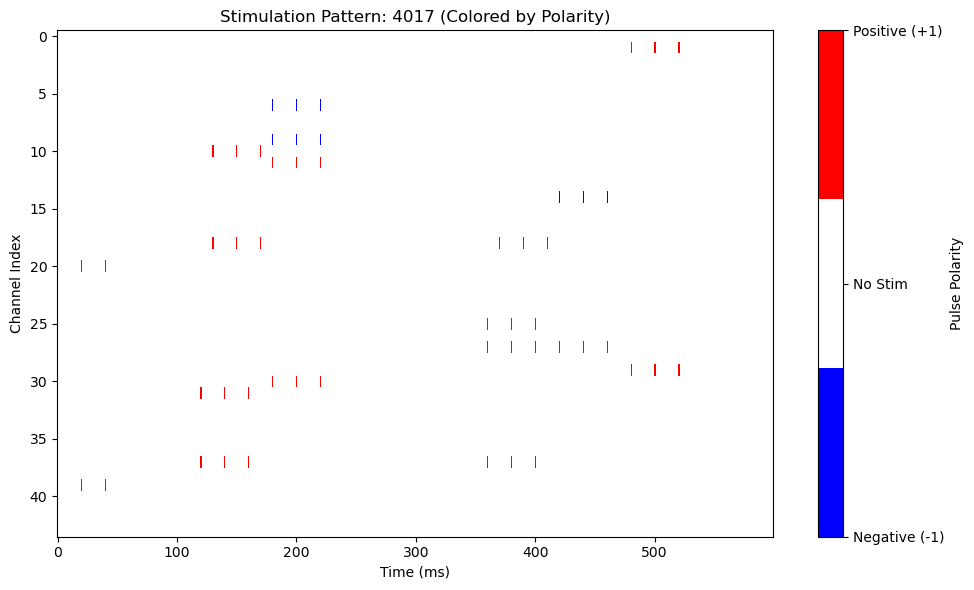

In [ ]:
# Example: Plot stimulation pattern for a specific pattern (colored by polarity)
from matplotlib.colors import ListedColormap

# Custom colormap: blue for negative polarity (-1), white for no stim (0), red for positive polarity (+1)
polarity_cmap = ListedColormap(['blue', 'white', 'red'])

for pattern_name in list(pattern_stims.keys())[:2]:  # just plot first 2 patterns
    stim = pattern_stims[pattern_name]
    polarity = pattern_polarities[pattern_name]
    print(f"Pattern {pattern_name}: stim shape {stim.shape}, polarity shape {polarity.shape}")
    
    # Plot the stimulation pattern colored by polarity
    plt.figure(figsize=(10, 6)) 
    im = plt.imshow(polarity, aspect='auto', cmap=polarity_cmap, vmin=-1, vmax=1, interpolation='nearest')
    cbar = plt.colorbar(im, label='Pulse Polarity', ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['Negative (-1)', 'No Stim', 'Positive (+1)'])
    plt.xlabel('Time (ms)')
    plt.ylabel('Channel Index')
    plt.title(f'Stimulation Pattern: {pattern_name} (Colored by Polarity)')
    plt.tight_layout()
    plt.show()

# ...existing code for oracle patterns...# Make a plot showing average for each oracle pattern across its 10 trials
oracle_patterns = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()
for pattern_name in oracle_patterns:  # just plot first 2 oracle patterns
    trials = unique_trials[unique_trials['pattern_name'] == pattern_name]
    avg_spike_response = np.zeros((len(spiking_neurons), 2000))
    for _, trial_info in trials.iterrows():
        timing_idx = trial_info['pattern_timing_index']
        avg_spike_response += spike_responses[timing_idx]
    avg_spike_response /= len(trials)
    
    # Plot the average spike response as a heatmap
    # plt.figure(figsize=(10, 6)) 
    # plt.imshow(avg_spike_response, aspect='auto', cmap='viridis', interpolation='nearest')
    # plt.colorbar(label='Average Spike Probability')
    # plt.xlabel('Time (ms)')
    # plt.ylabel('Neuron Index')
    # plt.title(f'Average Spike Response for Oracle Pattern: {pattern_name}')
    # plt.tight_layout()
    # plt.savefig(f'average_spike_response_oracle_pattern_{pattern_name}.png')
    # plt.close()

In [ ]:
# =====================
# Single-pulse STA at BinnedStimSpikeDataset granularity
# =====================
# Stim events = 10 ms INPUT BINS that contain stimulation, keyed by
# (electrode, polarity). Polarity is -1 for delay_mode == -1, else +1.
# For each clean stim event, collect the 10 ms of spikes immediately after,
# binned at 2 ms -> 5 bins (i.e. the window ending just before the next
# possible stim bin).
# Contamination rule: drop the event if ANY electrode is stimulated in the
# next 10 ms input bin (so spikes in the follow-window are not influenced
# by a subsequent stim).
#
# Uses DELAY_MODE_TO_INDEX from utils.py:
#   delay_mode 0, 1, 2  -> polarity +1
#   delay_mode -1       -> polarity -1

from utils import DELAY_MODE_TO_INDEX, NO_STIM_INDEX

INPUT_BIN_MS = 10
SPIKE_BIN_MS = 2
WINDOW_MS = INPUT_BIN_MS
N_BINS = WINDOW_MS // SPIKE_BIN_MS  # 5
MAX_TIME_MS = 2000
TOTAL_INPUT_BINS = MAX_TIME_MS // INPUT_BIN_MS  # 200

N_CHANNELS = len(channel_to_index)
N_NEURONS = len(spiking_neurons)
POLARITIES = [-1, 1]
POL_TO_IDX = {-1: 0, 1: 1}

# Polarity of each delay_mode category (index 0..3 in DELAY_MODE_TO_INDEX).
# delay_mode -> polarity
DELAY_POLARITY = {0: 1, 1: 1, -1: -1, 2: 1}
# category_idx -> polarity, using DELAY_MODE_TO_INDEX
CAT_IDX_TO_POLARITY = np.zeros(NO_STIM_INDEX + 1, dtype=np.int8)  # size 5
for dm, cat_idx in DELAY_MODE_TO_INDEX.items():
    CAT_IDX_TO_POLARITY[cat_idx] = DELAY_POLARITY[dm]
# NO_STIM_INDEX stays 0

# Build categorical stim per pattern at 10 ms bins, matching
# BinnedStimSpikeDataset._encode_pattern_binned ("categorical" mode).
def encode_pattern_binned_categorical(pattern_subset):
    stim = np.full((N_CHANNELS, TOTAL_INPUT_BINS), NO_STIM_INDEX, dtype=np.int64)
    for _, row in pattern_subset.iterrows():
        if pd.isna(row['channel']):
            continue
        step_index = int(row['step_index'])
        if step_index >= 10:  # only first 10 steps = 600 ms of stim
            continue
        channel_index = channel_to_index[int(row['channel'])]
        delay_mode = int(row['delay_mode'])
        category_idx = DELAY_MODE_TO_INDEX[delay_mode]
        step_start_ms = step_index * 60
        step_end_ms = step_start_ms + 60
        start_bin = step_start_ms // INPUT_BIN_MS
        end_bin = min(step_end_ms // INPUT_BIN_MS, TOTAL_INPUT_BINS)
        stim[channel_index, start_bin:end_bin] = category_idx
    return stim

pattern_stims_binned = {}
for pattern_name in pattern_df['pattern_name'].unique():
    subset = pattern_df[pattern_df['pattern_name'] == pattern_name].drop_duplicates(
        subset=['step_index', 'channel', 'delay_mode'])
    pattern_stims_binned[pattern_name] = encode_pattern_binned_categorical(subset)

# Bin spikes at 2 ms per trial
spike_responses_2ms = {}
for timing_idx, resp in spike_responses.items():
    r = resp[:, :MAX_TIME_MS]  # (n_neurons, 2000)
    # reshape into (n_neurons, n_bins, SPIKE_BIN_MS) and sum -> (n_neurons, n_bins)
    n_bins_total = MAX_TIME_MS // SPIKE_BIN_MS
    spike_responses_2ms[timing_idx] = r.reshape(N_NEURONS, n_bins_total, SPIKE_BIN_MS).sum(axis=2)

# Accumulate STA: (electrode, polarity, neuron, bin)
sta_counts = np.zeros((N_CHANNELS, len(POLARITIES), N_NEURONS, N_BINS), dtype=np.float64)
sta_n_trials = np.zeros((N_CHANNELS, len(POLARITIES)), dtype=np.int64)

BINS_PER_INPUT = INPUT_BIN_MS // SPIKE_BIN_MS  # 5 two-ms spike bins per 10 ms input bin

for timing_idx, spike_resp_2ms in spike_responses_2ms.items():
    pattern_name = timing_to_pattern[timing_idx]
    stim_cat = pattern_stims_binned[pattern_name]  # (N_CHANNELS, TOTAL_INPUT_BINS)
    # "any stim" per input bin (across electrodes)
    any_stim_per_bin = (stim_cat != NO_STIM_INDEX).any(axis=0)  # (TOTAL_INPUT_BINS,)

    # For each input bin t where we could have a valid follow-window (t+1 exists),
    # i.e. t in 0 .. TOTAL_INPUT_BINS - 2.
    # The follow-window in 2 ms spike bins is spike bins
    # [(t+1)*BINS_PER_INPUT, (t+2)*BINS_PER_INPUT).
    for t in range(TOTAL_INPUT_BINS - 1):
        # contamination: if any electrode is stimulated in bin t+1, skip
        if any_stim_per_bin[t + 1]:
            continue
        # find stimulated electrodes in bin t
        stim_mask_t = stim_cat[:, t] != NO_STIM_INDEX
        if not stim_mask_t.any():
            continue
        b0 = (t + 1) * BINS_PER_INPUT
        b1 = b0 + BINS_PER_INPUT  # = (t+2)*BINS_PER_INPUT
        window = spike_resp_2ms[:, b0:b1]  # (N_NEURONS, 5)
        # per-electrode polarity
        cats = stim_cat[stim_mask_t, t]  # categorical indices
        pols = CAT_IDX_TO_POLARITY[cats]  # (n_stim_electrodes,)
        elec_idx = np.nonzero(stim_mask_t)[0]
        for e, p in zip(elec_idx, pols):
            p_idx = POL_TO_IDX[int(p)]
            sta_counts[e, p_idx] += window
            sta_n_trials[e, p_idx] += 1

# Avoid div-by-zero
sta = np.zeros_like(sta_counts)
denom = sta_n_trials[:, :, None, None].astype(np.float64)
np.divide(sta_counts, denom, out=sta, where=denom > 0)

# Firing rate in Hz (spikes per 2ms bin / bin_width_sec)
sta_rate_hz = sta / (SPIKE_BIN_MS / 1000.0)

print(f"STA shape: {sta.shape}  (electrodes, polarities, neurons, 2ms bins)")
print(f"n_trials per (electrode, polarity) — min/median/max: "
      f"{sta_n_trials.min()}, {int(np.median(sta_n_trials))}, {sta_n_trials.max()}")
print(f"Electrodes with 0 clean stim bins at polarity -1: "
      f"{(sta_n_trials[:,0]==0).sum()} / {N_CHANNELS}")
print(f"Electrodes with 0 clean stim bins at polarity +1: "
      f"{(sta_n_trials[:,1]==0).sum()} / {N_CHANNELS}")


In [ ]:
# =====================
# Plot STA: per-electrode heatmaps (neurons x 5 bins), one figure per polarity
# =====================
idx_to_channel = {v: k for k, v in channel_to_index.items()}

for p_idx, pol_val in enumerate(POLARITIES):
    n_cols = 6
    n_rows = int(np.ceil(N_CHANNELS / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.2*n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    vmax = np.percentile(sta_rate_hz[:, p_idx], 99) if sta_rate_hz[:, p_idx].size else 1.0
    vmax = max(vmax, 1.0)
    im = None
    for e in range(N_CHANNELS):
        ax = axes[e // n_cols, e % n_cols]
        n_tr = sta_n_trials[e, p_idx]
        if n_tr == 0:
            ax.set_title(f"ch {int(idx_to_channel[e])} (n=0)", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        im = ax.imshow(sta_rate_hz[e, p_idx], aspect='auto', cmap='magma',
                       vmin=0, vmax=vmax, interpolation='nearest',
                       extent=[0, WINDOW_MS, N_NEURONS, 0])
        ax.set_title(f"ch {int(idx_to_channel[e])} (n={n_tr})", fontsize=8)
    for e in range(N_CHANNELS, n_rows*n_cols):
        axes[e // n_cols, e % n_cols].axis('off')
    fig.suptitle(f"Single-bin STA (polarity {pol_val:+d}) — firing rate (Hz), "
                 f"10 ms window after 10 ms stim bin, 2 ms spike bins", fontsize=12)
    fig.supxlabel("Time after stim bin (ms)")
    fig.supylabel("Neuron index")
    fig.tight_layout(rect=[0, 0, 0.96, 0.97])
    if im is not None:
        cbar_ax = fig.add_axes([0.97, 0.15, 0.012, 0.7])
        fig.colorbar(im, cax=cbar_ax, label="Firing rate (Hz)")
    plt.show()

# Population-mean per electrode, each polarity
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bin_centers = np.arange(N_BINS) * SPIKE_BIN_MS + SPIKE_BIN_MS/2
for p_idx, pol_val in enumerate(POLARITIES):
    ax = axes[p_idx]
    for e in range(N_CHANNELS):
        if sta_n_trials[e, p_idx] == 0:
            continue
        pop = sta_rate_hz[e, p_idx].mean(axis=0)
        ax.plot(bin_centers, pop, alpha=0.4, lw=1)
    ax.set_title(f"Polarity {pol_val:+d} (pop-mean per electrode)")
    ax.set_xlabel("Time after stim bin (ms)")
    ax.set_ylabel("Mean firing rate across neurons (Hz)")
    ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from datetime import datetime
import json

# =====================
# Experiment Configuration
# =====================
INFERENCE_MODE = False  # Set to True to run inference from a saved model
ARTIFACT_PATH = None  # Set to a timestamped folder path (e.g., 'results/2026-01-23_14-30-00') for inference mode
SEED = 42  # Random seed for reproducibility
# Create timestamped results folder for this run
if INFERENCE_MODE and ARTIFACT_PATH:
    RUN_DIR = ARTIFACT_PATH
else:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    RUN_DIR = os.path.join("results", timestamp)
    os.makedirs(RUN_DIR, exist_ok=True)

# =====================
# Setup Logging
# =====================
# Remove any existing handlers to avoid duplicate logs
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_file = os.path.join(RUN_DIR, "experiment.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()  # Also output to console
    ]
)
logger = logging.getLogger(__name__)

logger.info(f"{'='*50}")
logger.info(f"Experiment run directory: {RUN_DIR}")
logger.info(f"Inference mode: {INFERENCE_MODE}")
logger.info(f"Random seed: {SEED}")
if INFERENCE_MODE:
    logger.info(f"Loading artifacts from: {ARTIFACT_PATH}")
logger.info(f"{'='*50}")

# =====================
# PyTorch Dataset
# =====================
# Mapping from delay_mode to integer index for categorical encoding
# Index 4 = no stimulation (default)
DELAY_MODE_TO_INDEX = {0: 0, 1: 1, -1: 2, 2: 3}  # delay_mode -> category index
NO_STIM_INDEX = 4  # Category for no stimulation
NUM_STIM_LEVELS = 5  # Total categories: 4 delay modes + 1 no-stim

# Legacy mappings (kept for backward compatibility)
DELAY_MODE_TO_INDICATOR = {0: 1, 1: 2, -1: 3, 2: 4}
DELAY_MODE_TO_ONEHOT_IDX = {0: 0, 1: 1, -1: 2, 2: 3}

class StimSpikeDataset(Dataset):
    """
    Dataset for stimulation patterns and spike responses.
    
    Time series can be truncated to any length between 600ms and 2000ms via truncate_ms parameter.
    - First 600ms: stimulation pattern encoded
    - Remaining time up to truncate_ms: no stimulation
    
    Encoding modes:
        'categorical_step': (44, n_bins) - Integer indices [0-4] for nn.Embedding (RECOMMENDED)
        'categorical': (44, truncate_ms) - Integer indices at 1ms resolution
        'one_hot_step': (44, n_bins, 5) - One-hot vectors (legacy)
        'one_hot': (44, truncate_ms, 5) - One-hot at 1ms resolution (legacy)
        'original_step': (44, n_bins) - Float values 0-4 (legacy)
        'original': (44, truncate_ms) - Float values (legacy)
    
    Outputs (Y):
        (n_neurons, truncate_ms/spike_bin_size) - binned spike counts
    """
    def __init__(self, pattern_df, spike_responses, channel_to_index, timing_to_pattern, 
                 trial_indices=None, encoding_mode='categorical_step', spike_bin_size=10, truncate_ms=2000):
        """
        Args:
            pattern_df: DataFrame with step-level stimulation information (pattern_name, step_index, channel, delay_mode)
            spike_responses: dict mapping pattern_timing_index -> (n_neurons, 2000) numpy array
            channel_to_index: dict mapping channel name -> index
            timing_to_pattern: dict mapping pattern_timing_index -> pattern_name
            trial_indices: list of pattern_timing_index values to include (for train/val/test splits)
            encoding_mode: 'categorical_step', 'categorical', 'one_hot_step', 'one_hot', 'original_step', 'original'
            spike_bin_size: (ms) length of time spikes to predict are binned over. Larger bin sizes should use Poisson NLL Loss.
            truncate_ms: (ms) total time series length (600-2000). Must be >= 600 and divisible by spike_bin_size and input_bin_size.
        """
        if trial_indices is None:
            trial_indices = list(spike_responses.keys())
        
        # Validate truncate_ms
        assert 600 <= truncate_ms <= 2000, f"truncate_ms must be between 600 and 2000, got {truncate_ms}"
        assert truncate_ms % spike_bin_size == 0, f"truncate_ms ({truncate_ms}) must be divisible by spike_bin_size ({spike_bin_size})"
        
        # Input bin size depends on encoding mode (step modes use 10ms bins)
        self.input_bin_size = 10 if 'step' in encoding_mode else 1
        assert truncate_ms % self.input_bin_size == 0, f"truncate_ms ({truncate_ms}) must be divisible by input_bin_size ({self.input_bin_size})"
        
        self.trial_indices = trial_indices
        self.timing_to_pattern = timing_to_pattern
        self.encoding_mode = encoding_mode
        self.n_channels = len(channel_to_index)
        self.spike_bin_size = spike_bin_size
        self.truncate_ms = truncate_ms
        self.n_input_bins = truncate_ms // self.input_bin_size
        self.n_output_bins = truncate_ms // spike_bin_size
        
        # Determine if using categorical (integer) encoding
        self.is_categorical = 'categorical' in encoding_mode
        
        self.X = []
        self.Y = []
        
        for timing_idx in trial_indices:
            pattern_name = timing_to_pattern[timing_idx]
            pattern_subset = pattern_df[pattern_df['pattern_name'] == pattern_name].drop_duplicates(subset=['step_index', 'channel', 'delay_mode'])
            stim = self._encode_pattern(pattern_subset, channel_to_index)
            
            # Use LongTensor for categorical (embedding input), FloatTensor otherwise
            if self.is_categorical:
                self.X.append(torch.tensor(stim, dtype=torch.long))
            else:
                self.X.append(torch.tensor(stim, dtype=torch.float32))
            
            # Get spike response and truncate to truncate_ms before binning
            spike_resp = spike_responses[timing_idx][:, :truncate_ms]  # Truncate to desired length
            spike_resp = self._bin_spike_response(spike_resp, bin_size=spike_bin_size)
            self.Y.append(torch.tensor(spike_resp, dtype=torch.float32))
        
        self.X = torch.stack(self.X)
        self.Y = torch.stack(self.Y)
    
    def _bin_spike_response(self, spike_resp, bin_size=10):
        """Bin spike responses to specified bin size.
        
        Args:
            spike_resp: (n_neurons, truncate_ms) numpy array with binary spike indicators
            bin_size: number of ms per bin (default 10)
        Returns:
            binned_resp: (n_neurons, n_bins) numpy array with spike counts per bin
        """
        n_neurons, n_time = spike_resp.shape
        n_bins = n_time // bin_size
        # Reshape to (n_neurons, n_bins, bin_size) and sum spikes in each bin
        reshaped = spike_resp[:, :n_bins * bin_size].reshape(n_neurons, n_bins, bin_size)
        binned = reshaped.sum(axis=2).astype(np.float32)
        return binned
        
    def _encode_pattern(self, pattern_subset, channel_to_index):
        """Encode a single pattern based on the encoding mode.
        
        Uses self.truncate_ms to determine output length:
        - First 600ms: stimulation pattern
        - Remaining time up to truncate_ms: no stimulation
        """
        n_channels = len(channel_to_index)
        truncate_ms = self.truncate_ms
        n_input_bins = self.n_input_bins
        
        if self.encoding_mode == 'categorical_step':
            # (44, n_input_bins) - Integer indices for nn.Embedding
            # Values: 0-3 = delay modes, 4 = no stimulation
            stim = np.full((n_channels, n_input_bins), NO_STIM_INDEX, dtype=np.int64)
            
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = int(row['step_index'])
                if step_index >= 10:
                    continue
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                category_idx = DELAY_MODE_TO_INDEX[delay_mode]
                
                # Each original 60ms step maps to 6 bins of 10ms each
                for bin_offset in range(6):
                    bin_idx = step_index * 6 + bin_offset
                    if bin_idx < 60 and bin_idx < n_input_bins:
                        stim[channel_index, bin_idx] = category_idx
            return stim
        
        elif self.encoding_mode == 'categorical':
            # (44, truncate_ms) - Integer indices at 1ms resolution
            stim = np.full((n_channels, truncate_ms), NO_STIM_INDEX, dtype=np.int64)
            
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = row['step_index']
                stim_ms = 60 * step_index
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                category_idx = DELAY_MODE_TO_INDEX[delay_mode]
                
                if delay_mode == 0:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = category_idx
                elif delay_mode == 1:
                    for pulse in range(3):
                        pulse_time = stim_ms + 10 + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = category_idx
                elif delay_mode == -1:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = category_idx
                elif delay_mode == 2:
                    for pulse in range(6):
                        pulse_time = stim_ms + pulse * 10
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = category_idx
            return stim
        
        elif self.encoding_mode == 'original':
            # (44, truncate_ms) with 3 at stimulation timepoints in first 600ms, zeros for rest
            stim = np.zeros((n_channels, truncate_ms))
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = row['step_index']
                stim_ms = 60 * step_index
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                
                if delay_mode == 0:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = 3
                elif delay_mode == 1:
                    for pulse in range(3):
                        pulse_time = stim_ms + 10 + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = 3
                elif delay_mode == -1:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = 3
                elif delay_mode == 2:
                    for pulse in range(6):
                        pulse_time = stim_ms + pulse * 10
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time] = 3
            return stim
        
        elif self.encoding_mode == 'one_hot':
            # (44, truncate_ms, 5) - one-hot encoding at each timepoint
            stim = np.zeros((n_channels, truncate_ms, 5))
            stim[:, :, 4] = 1  # Default: no stimulation (index 4)
            
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = row['step_index']
                stim_ms = 60 * step_index
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                onehot_idx = DELAY_MODE_TO_ONEHOT_IDX[delay_mode]
                
                if delay_mode == 0:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time, :] = 0
                            stim[channel_index, pulse_time, onehot_idx] = 1
                elif delay_mode == 1:
                    for pulse in range(3):
                        pulse_time = stim_ms + 10 + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time, :] = 0
                            stim[channel_index, pulse_time, onehot_idx] = 1
                elif delay_mode == -1:
                    for pulse in range(3):
                        pulse_time = stim_ms + pulse * 20
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time, :] = 0
                            stim[channel_index, pulse_time, onehot_idx] = 1
                elif delay_mode == 2:
                    for pulse in range(6):
                        pulse_time = stim_ms + pulse * 10
                        if pulse_time < 600 and pulse_time < truncate_ms:
                            stim[channel_index, pulse_time, :] = 0
                            stim[channel_index, pulse_time, onehot_idx] = 1
            return stim
        
        elif self.encoding_mode == 'original_step':
            # (44, n_input_bins) - n_input_bins bins of 10ms each covering truncate_ms
            stim = np.zeros((n_channels, n_input_bins))
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = int(row['step_index'])
                if step_index >= 10:
                    continue
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                for bin_offset in range(6):
                    bin_idx = step_index * 6 + bin_offset
                    if bin_idx < 60 and bin_idx < n_input_bins:
                        stim[channel_index, bin_idx] = DELAY_MODE_TO_INDICATOR[delay_mode]
            return stim
        
        elif self.encoding_mode == 'one_hot_step':
            # (44, n_input_bins, 5) - n_input_bins bins of 10ms each covering truncate_ms
            stim = np.zeros((n_channels, n_input_bins, 5))
            stim[:, :, 4] = 1  # Default: no stimulation (index 4)
            
            for _, row in pattern_subset.iterrows():
                if pd.isna(row['channel']):
                    continue
                step_index = int(row['step_index'])
                if step_index >= 10:
                    continue
                channel_index = channel_to_index[int(row['channel'])]
                delay_mode = int(row['delay_mode'])
                onehot_idx = DELAY_MODE_TO_ONEHOT_IDX[delay_mode]
                for bin_offset in range(6):
                    bin_idx = step_index * 6 + bin_offset
                    if bin_idx < 60 and bin_idx < n_input_bins:
                        stim[channel_index, bin_idx, :] = 0
                        stim[channel_index, bin_idx, onehot_idx] = 1
            return stim
        
        else:
            raise ValueError(f"Unknown encoding_mode: {self.encoding_mode}")
        
    def __len__(self):
        return len(self.trial_indices)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# =====================
# Create Train/Val/Test Splits
# =====================
# Now we split by timing_index (unique per trial) instead of pattern_name
all_timing_indices = list(spike_responses.keys())
logger.info(f"Total trials: {len(all_timing_indices)}")

# Get unique trials info for splitting
unique_trials_info = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()

# Split mode: 'oracle' or 'random'
# - 'oracle': test set uses all 10 trials from each of 50 oracle patterns (500 total), train/val use non-oracle trials
# - 'random': random split across all trials
SPLIT_MODE = 'oracle'  # or 'random'

if SPLIT_MODE == 'oracle':
    # Separate oracle trials (all 10 trials of patterns 4001-4050) from sample trials
    oracle_timing_indices = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    sample_timing_indices = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    
    logger.info(f"Oracle trials: {len(oracle_timing_indices)} (50 patterns x 10 trials)")
    logger.info(f"Sample trials: {len(sample_timing_indices)}")
    
    # Test set = all oracle trials (500 trials: 50 patterns x 10 repeats)
    test_indices = oracle_timing_indices
    
    # Split sample trials into train (85%) and val (15%)
    train_indices, val_indices = train_test_split(sample_timing_indices, test_size=0.15, random_state=SEED)
    
    logger.info(f"Train: {len(train_indices)} (sample only), Val: {len(val_indices)} (sample only), Test: {len(test_indices)} (all oracle trials)")

elif SPLIT_MODE == 'random':
    # Random split across all trials
    train_val_indices, test_indices = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.176, random_state=SEED)  # 0.176 of 0.85 ≈ 0.15 of total
    
    logger.info(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")
else:
    raise ValueError(f"Unknown split mode: {SPLIT_MODE}")

logger.info(f"Split mode: {SPLIT_MODE}")

# Choose encoding mode:
# - 'categorical_step': Integer indices for nn.Embedding (RECOMMENDED - faster, less memory)
# - 'categorical': Integer indices at 1ms resolution
# - 'one_hot_step': One-hot vectors at 10ms bins (legacy)
# - 'one_hot': One-hot at 1ms resolution (legacy)
# - 'original_step': Float values (legacy)
# - 'original': Float values at 1ms (legacy)
ENCODING_MODE = 'categorical_step'  # Use categorical for nn.Embedding
logger.info(f"Encoding mode: {ENCODING_MODE}")
SPIKE_BIN_SIZE = 100 if 'step' in ENCODING_MODE else 10  # 100ms bins for step modes, 10ms for original modes
TRUNCATE_MS = 1000  # Time series length in ms (600-2000). Set to 1000 for faster training, 2000 for full data.

# Create datasets with truncation
train_dataset = StimSpikeDataset(pattern_df, spike_responses, channel_to_index, timing_to_pattern, 
                                  train_indices, encoding_mode=ENCODING_MODE, spike_bin_size=SPIKE_BIN_SIZE, truncate_ms=TRUNCATE_MS)
val_dataset = StimSpikeDataset(pattern_df, spike_responses, channel_to_index, timing_to_pattern, 
                                val_indices, encoding_mode=ENCODING_MODE, spike_bin_size=SPIKE_BIN_SIZE, truncate_ms=TRUNCATE_MS)
test_dataset = StimSpikeDataset(pattern_df, spike_responses, channel_to_index, timing_to_pattern, 
                                 test_indices, encoding_mode=ENCODING_MODE, spike_bin_size=SPIKE_BIN_SIZE, truncate_ms=TRUNCATE_MS)

# Create dataloaders
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

logger.info(f"Truncate length: {TRUNCATE_MS}ms")
logger.info(f"Spike bin size: {SPIKE_BIN_SIZE}ms -> {train_dataset.n_output_bins} output bins")
logger.info(f"Input bin size: {train_dataset.input_bin_size}ms -> {train_dataset.n_input_bins} input bins")
logger.info(f"Is categorical (uses nn.Embedding): {train_dataset.is_categorical}")
logger.info(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
logger.info(f"Input shape (X): {train_dataset.X.shape}, dtype: {train_dataset.X.dtype}")
logger.info(f"Output shape (Y): {train_dataset.Y.shape}")

n_stim_channels = train_dataset.X.shape[1]
n_neurons = train_dataset.Y.shape[1]
logger.info(f"Number of stimulation channels: {n_stim_channels}")
logger.info(f"Number of recorded neurons: {n_neurons}")

# =====================
# Device Setup with MPS/Apple Silicon Optimization
# =====================
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
    logger.info(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = 'Apple Silicon (MPS)'
    os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
    logger.info(f"Using Apple Silicon MPS acceleration")
    logger.info(f"MPS built: {torch.backends.mps.is_built()}")
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    logger.info(f"Using CPU (no GPU acceleration available)")

logger.info(f"PyTorch version: {torch.__version__}")
logger.info(f"Device: {device}")

# Save experiment config
config = {
    'timestamp': datetime.now().isoformat(),
    'artifact_path': ARTIFACT_PATH,
    'inference_mode': INFERENCE_MODE,
    'seed': SEED,
    'split_mode': SPLIT_MODE,
    'encoding_mode': ENCODING_MODE,
    'is_categorical': train_dataset.is_categorical,
    'spike_bin_size': SPIKE_BIN_SIZE,
    'truncate_ms': TRUNCATE_MS,
    'n_input_bins': train_dataset.n_input_bins,
    'n_output_bins': train_dataset.n_output_bins,
    'batch_size': BATCH_SIZE,
    'train_size': len(train_indices),
    'val_size': len(val_indices),
    'test_size': len(test_indices),
    'input_shape': list(train_dataset.X.shape),
    'output_shape': list(train_dataset.Y.shape),
    'device': str(device),
    'device_name': device_name,
    'pytorch_version': torch.__version__,
    'mps_available': torch.backends.mps.is_available(),
    'mps_built': torch.backends.mps.is_built() if hasattr(torch.backends.mps, 'is_built') else False,
    'cuda_available': torch.cuda.is_available()
}

with open(os.path.join(RUN_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

logger.info(f"Saved experiment config to {os.path.join(RUN_DIR, 'config.json')}")

2026-01-28 13:21:19,633 - INFO - ==================================================
2026-01-28 13:21:19,634 - INFO - Experiment run directory: results/2026-01-28_13-21-19
2026-01-28 13:21:19,635 - INFO - Inference mode: False
2026-01-28 13:21:19,635 - INFO - Random seed: 42
2026-01-28 13:21:19,636 - INFO - ==================================================
2026-01-28 13:21:19,638 - INFO - Total trials: 5000
2026-01-28 13:21:19,655 - INFO - Oracle trials: 1000 (50 patterns x 10 trials)
2026-01-28 13:21:19,655 - INFO - Sample trials: 4000
2026-01-28 13:21:19,657 - INFO - Train: 3400 (sample only), Val: 600 (sample only), Test: 1000 (all oracle trials)
2026-01-28 13:21:19,657 - INFO - Split mode: oracle
2026-01-28 13:21:19,657 - INFO - Encoding mode: categorical_step
2026-01-28 13:21:39,388 - INFO - Truncate length: 1000ms
2026-01-28 13:21:39,390 - INFO - Spike bin size: 100ms -> 10 output bins
2026-01-28 13:21:39,391 - INFO - Input bin size: 10ms -> 100 input bins
2026-01-28 13:21:39,391

In [90]:
# =====================
# RNN Model
# =====================
class StimToSpikeRNN(nn.Module):
    """
    RNN model that maps stimulation patterns to spike responses.
    
    Supports different encoding modes:
    - 'categorical_step': Input (batch, 44, n_bins) with integer indices -> nn.Embedding -> RNN
    - 'categorical': Input (batch, 44, time) with integer indices -> nn.Embedding -> RNN
    - 'original': Input (batch, 44, 2000) -> RNN input_size = 44
    - 'one_hot': Input (batch, 44, 2000, 5) -> RNN input_size = 44 * 5 = 220
    - 'original_step': Input (batch, 44, 200) -> RNN input_size = 44
    - 'one_hot_step': Input (batch, 44, 200, 5) -> RNN input_size = 44 * 5 = 220
    
    Output temporal resolution can differ from input via output_bin_size parameter.
    The model aggregates RNN outputs to match the target bin size.
    
    Output: (batch, n_neurons, n_output_bins)
    """
    def __init__(self, 
                 n_stim_channels, 
                 n_neurons,
                 encoding_mode='categorical_step',
                 hidden_size=128,
                 num_layers=2,
                 dropout=0.2,
                 prediction_type="spike",
                 bidirectional=False,
                 input_bin_size=10,
                 output_bin_size=10,
                 embedding_dim=8,
                 num_stim_levels=5):
        """
        Args:
            n_stim_channels: Number of stimulation channels (44)
            n_neurons: Number of neurons to predict (63)
            encoding_mode: One of 'categorical_step', 'categorical', 'original', 'one_hot', 'original_step', 'one_hot_step'
            hidden_size: RNN hidden state size
            num_layers: Number of RNN layers
            dropout: Dropout rate (only applied if num_layers > 1)
            prediction_type: Type of prediction (unused, kept for compatibility)
            bidirectional: Whether to use bidirectional RNN
            input_bin_size: Temporal resolution of input in ms (e.g., 10ms for step modes)
            output_bin_size: Temporal resolution of output/targets in ms (e.g., 100ms)
            embedding_dim: Dimension of learned embeddings for categorical modes
            num_stim_levels: Number of stimulation categories (5: 4 delay modes + 1 no-stim)
        """
        super().__init__()
        
        self.n_stim_channels = n_stim_channels
        self.n_neurons = n_neurons
        self.encoding_mode = encoding_mode
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.input_bin_size = input_bin_size
        self.output_bin_size = output_bin_size
        self.embedding_dim = embedding_dim
        self.num_stim_levels = num_stim_levels
        
        # Determine if using categorical (embedding) mode
        self.is_categorical = 'categorical' in encoding_mode
        
        # Calculate aggregation factor (how many input bins per output bin)
        assert output_bin_size >= input_bin_size, "output_bin_size must be >= input_bin_size"
        assert output_bin_size % input_bin_size == 0, "output_bin_size must be divisible by input_bin_size"
        self.agg_factor = output_bin_size // input_bin_size
        
        # Determine RNN input size based on encoding mode
        if self.is_categorical:
            # Use learned embeddings for each stimulation level
            # Each channel gets embedded, then concatenated: n_channels * embedding_dim
            self.embedding = nn.Embedding(num_embeddings=num_stim_levels, embedding_dim=embedding_dim)
            self.rnn_input_size = n_stim_channels * embedding_dim
        elif encoding_mode in ['one_hot', 'one_hot_step']:
            # One-hot: 5 categories per channel
            self.embedding = None
            self.rnn_input_size = n_stim_channels * 5
        else:
            # Original: just the raw values per channel
            self.embedding = None
            self.rnn_input_size = n_stim_channels
        
        # RNN processes time steps of stimulation
        self.rnn = nn.GRU(
            input_size=self.rnn_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        rnn_output_size = hidden_size * (2 if bidirectional else 1)
        
        # If aggregating, we concatenate hidden states from multiple timesteps
        # This gives the output layer more context for each output bin
        self.output_layer = nn.Sequential(
            nn.Linear(rnn_output_size * self.agg_factor, n_neurons),
        )
        
    def forward(self, x):
        """
        Args:
            x: Stimulation patterns. Shape depends on encoding_mode:
               - 'categorical'/'categorical_step': (batch, channels, time) - LongTensor with indices
               - 'original'/'original_step': (batch, channels, time) - FloatTensor
               - 'one_hot'/'one_hot_step': (batch, channels, time, 5) - FloatTensor
        Returns:
            y: (batch, neurons, n_output_bins) - predicted spike responses at output resolution
        """
        batch_size = x.shape[0]
        
        if self.is_categorical:
            # Input shape: (batch, channels, time) with integer indices
            # Permute to: (batch, time, channels)
            x = x.permute(0, 2, 1)
            # x shape: (batch, time, channels)
            
            # Apply embedding: (batch, time, channels) -> (batch, time, channels, embedding_dim)
            x = self.embedding(x)
            
            # Flatten channels and embedding dims: (batch, time, channels * embedding_dim)
            x = x.reshape(batch_size, x.shape[1], -1)
            
        elif self.encoding_mode in ['one_hot', 'one_hot_step']:
            # Input shape: (batch, channels, time, 5)
            # Permute to: (batch, time, channels, 5)
            x = x.permute(0, 2, 1, 3)
            # Flatten last two dims: (batch, time, channels * 5)
            x = x.reshape(batch_size, x.shape[1], -1)
        else:
            # Input shape: (batch, channels, time)
            # Permute to: (batch, time, channels) for RNN
            x = x.permute(0, 2, 1)
        
        # x shape: (batch, n_input_bins, features)
        n_input_bins = x.shape[1]
        
        # Convert to float for RNN (embedding output is already float)
        if not self.is_categorical and x.dtype != torch.float32:
            x = x.float()
        
        # Process through RNN
        # rnn_out shape: (batch, n_input_bins, hidden_size * num_directions)
        rnn_out, _ = self.rnn(x)
        
        # Aggregate RNN outputs to match target resolution
        # Reshape to group input bins that belong to same output bin
        n_output_bins = n_input_bins // self.agg_factor
        rnn_hidden_size = rnn_out.shape[2]
        
        # (batch, n_input_bins, hidden) -> (batch, n_output_bins, agg_factor, hidden)
        rnn_out = rnn_out.reshape(batch_size, n_output_bins, self.agg_factor, rnn_hidden_size)
        
        # Concatenate hidden states within each output bin
        # (batch, n_output_bins, agg_factor, hidden) -> (batch, n_output_bins, agg_factor * hidden)
        rnn_out = rnn_out.reshape(batch_size, n_output_bins, self.agg_factor * rnn_hidden_size)
        
        # Project to neuron space
        # output shape: (batch, n_output_bins, n_neurons)
        output = self.output_layer(rnn_out)
        
        # Permute to channel-first format
        # (batch, n_output_bins, neurons) -> (batch, neurons, n_output_bins)
        output = output.permute(0, 2, 1)
        
        return output

# Determine input bin size based on encoding mode
INPUT_BIN_SIZE = 10 if 'step' in ENCODING_MODE else 1  # 10ms for step modes, 1ms for original

# Embedding dimension for categorical modes
EMBEDDING_DIM = 8  # Learned embedding size per stimulation level

# Initialize model with proper bin sizes
model = StimToSpikeRNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    encoding_mode=ENCODING_MODE,
    hidden_size=32,
    num_layers=1,
    dropout=0.2,
    bidirectional=False,
    input_bin_size=INPUT_BIN_SIZE,
    output_bin_size=SPIKE_BIN_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_stim_levels=NUM_STIM_LEVELS
).to(device)

logger.info(f"Encoding mode: {ENCODING_MODE}")
logger.info(f"Is categorical (uses nn.Embedding): {model.is_categorical}")
if model.is_categorical:
    logger.info(f"Embedding: {NUM_STIM_LEVELS} levels -> {EMBEDDING_DIM}-dim vectors")
logger.info(f"Input bin size: {INPUT_BIN_SIZE}ms, Output bin size: {SPIKE_BIN_SIZE}ms")
logger.info(f"Aggregation factor: {model.agg_factor} (concatenating {model.agg_factor} hidden states per output)")
logger.info(f"RNN input size: {model.rnn_input_size}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Total parameters: {total_params:,}")
logger.info(f"Trainable parameters: {trainable_params:,}")

# Test forward pass
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    sample_out = model(sample_x)
logger.info(f"Input shape: {sample_x.shape}, dtype: {sample_x.dtype}")
logger.info(f"Output shape: {sample_out.shape}")
logger.info(f"Target shape: {sample_y.shape}")

# Verify shapes match
assert sample_out.shape == sample_y.shape, f"Shape mismatch! Output: {sample_out.shape}, Target: {sample_y.shape}"
logger.info("✓ Output and target shapes match!")

2026-01-28 13:21:48,893 - INFO - Encoding mode: categorical_step
2026-01-28 13:21:48,894 - INFO - Is categorical (uses nn.Embedding): True
2026-01-28 13:21:48,894 - INFO - Embedding: 5 levels -> 8-dim vectors
2026-01-28 13:21:48,894 - INFO - Input bin size: 10ms, Output bin size: 100ms
2026-01-28 13:21:48,895 - INFO - Aggregation factor: 10 (concatenating 10 hidden states per output)
2026-01-28 13:21:48,896 - INFO - RNN input size: 336
2026-01-28 13:21:48,896 - INFO - Total parameters: 55,783
2026-01-28 13:21:48,896 - INFO - Trainable parameters: 55,783
2026-01-28 13:21:48,919 - INFO - Input shape: torch.Size([8, 42, 100]), dtype: torch.int64
2026-01-28 13:21:48,919 - INFO - Output shape: torch.Size([8, 63, 10])
2026-01-28 13:21:48,920 - INFO - Target shape: torch.Size([8, 63, 10])
2026-01-28 13:21:48,921 - INFO - ✓ Output and target shapes match!


In [91]:
# show some sample outputs
logger.info("Sample model outputs (first batch):")
for i in range(min(2, sample_out.shape[0])):  # show first 2 samples
    logger.info(f"Sample {i} labels (neuron 0, first 20 time bins): {sample_y[i, 0, :].cpu().numpy()}")
for i in range(min(2, sample_out.shape[0])):  # show first 2 samples
    logger.info(f"Sample {i} model output (neuron 0, first 20 time bins): {sample_out[i, 0, :20].cpu().numpy()}")
# =====================

2026-01-28 13:21:50,853 - INFO - Sample model outputs (first batch):
2026-01-28 13:21:50,855 - INFO - Sample 0 labels (neuron 0, first 20 time bins): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2026-01-28 13:21:50,856 - INFO - Sample 1 labels (neuron 0, first 20 time bins): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2026-01-28 13:21:50,861 - INFO - Sample 0 model output (neuron 0, first 20 time bins): [ 0.01890457  0.04548258  0.02216915 -0.05655544 -0.03046248  0.05819329
 -0.01413658 -0.02025954 -0.02293535 -0.02384612]
2026-01-28 13:21:50,863 - INFO - Sample 1 model output (neuron 0, first 20 time bins): [ 0.21557039  0.0215419  -0.24458191 -0.02359555 -0.00733494 -0.08881364
 -0.05954076 -0.03289712 -0.02855674 -0.0261815 ]


In [92]:
# =====================
# Training Loop
# =====================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch_x, batch_y in pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_x.size(0)
        pbar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    pbar = tqdm(loader, desc="Validating", leave=False)
    with torch.no_grad():
        for batch_x, batch_y in pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            total_loss += loss.item() * batch_x.size(0)
            pbar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(loader.dataset)


In [93]:

# Skip training if in inference mode
if not INFERENCE_MODE:
    # Training configuration
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 0
    CRITERION_FN = "poisson"
    
    # Loss function - Poisson NLL since spike responses are counts
    if CRITERION_FN == "poisson": 
        criterion = nn.PoissonNLLLoss(log_input=True)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(1.0))

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'lr': []
    }

    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 10

    # Model save path
    model_save_path = os.path.join(RUN_DIR, 'best_stim_spike_model.pt')

    logger.info("Starting training...")
    logger.info("=" * 50)

    # Log training config
    train_config = {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'criterion': CRITERION_FN,
        'patience': PATIENCE
    }
    with open(os.path.join(RUN_DIR, 'train_config.json'), 'w') as f:
        json.dump(train_config, f, indent=2)

    epoch_pbar = tqdm(range(NUM_EPOCHS), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Log progress
        epoch_pbar.set_postfix({
            'train_loss': f'{train_loss:.6f}',
            'val_loss': f'{val_loss:.6f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        logger.info(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), model_save_path)
            logger.info(f"Saved best model to {model_save_path}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                logger.info(f"Early stopping at epoch {epoch+1}")
                break

    logger.info("=" * 50)
    logger.info(f"Training complete! Best validation loss: {best_val_loss:.6f}")

    # Save training history
    history_path = os.path.join(RUN_DIR, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    logger.info(f"Saved training history to {history_path}")
else:
    logger.info("Skipping training - Inference mode enabled")
    # Load training history from artifact path if available
    history_path = os.path.join(ARTIFACT_PATH, 'training_history.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        logger.info(f"Loaded training history from {history_path}")
    else:
        history = None
        logger.warning(f"No training history found at {history_path}")

2026-01-28 13:21:57,640 - INFO - Starting training...
2026-01-28 13:21:57,641 - INFO - ==================================================
Epochs:   0%|          | 0/50 [01:18<?, ?it/s, train_loss=0.169425, val_loss=0.076413, lr=1.00e-04]2026-01-28 13:23:16,360 - INFO - Epoch   1/50 | Train Loss: 0.169425 | Val Loss: 0.076413 | LR: 1.00e-04
2026-01-28 13:23:16,370 - INFO - Saved best model to results/2026-01-28_13-21-19/best_stim_spike_model.pt
Epochs:   2%|▏         | 1/50 [02:31<1:04:17, 78.72s/it, train_loss=0.075094, val_loss=0.073970, lr=1.00e-04]2026-01-28 13:24:28,848 - INFO - Epoch   2/50 | Train Loss: 0.075094 | Val Loss: 0.073970 | LR: 1.00e-04
2026-01-28 13:24:28,855 - INFO - Saved best model to results/2026-01-28_13-21-19/best_stim_spike_model.pt
Epochs:   4%|▍         | 2/50 [03:40<1:00:02, 75.05s/it, train_loss=0.074320, val_loss=0.073851, lr=1.00e-04]2026-01-28 13:25:37,715 - INFO - Epoch   3/50 | Train Loss: 0.074320 | Val Loss: 0.073851 | LR: 1.00e-04
2026-01-28 13:25:3

Test Loss (BCE): 0.071796
Test predictions shape: torch.Size([1000, 63, 10])
Test targets shape: torch.Size([1000, 63, 10])


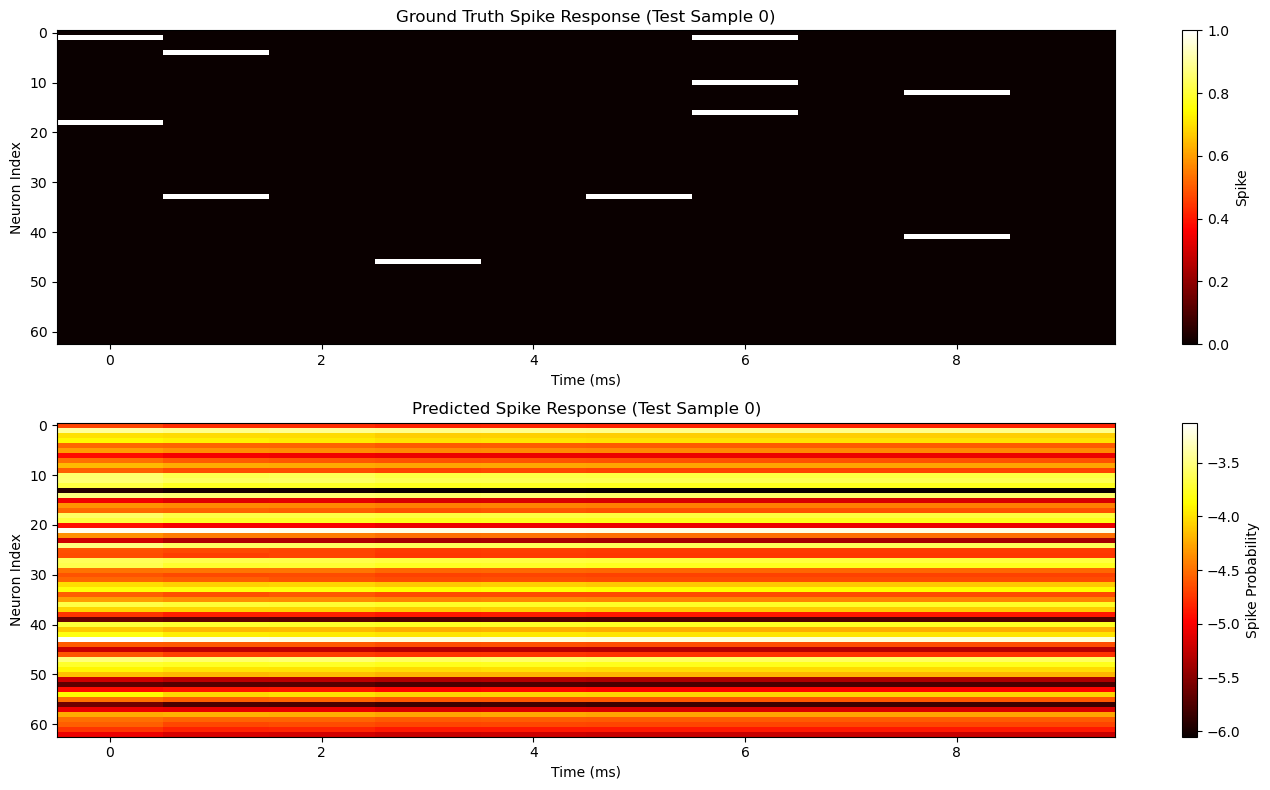

In [94]:
# =====================
# Evaluate on Test Set
# =====================
# Load best model
model.load_state_dict(torch.load(os.path.join(RUN_DIR, 'best_stim_spike_model.pt')))

test_loss = validate(model, test_loader, criterion, device)
print(f"Test Loss (BCE): {test_loss:.6f}")

# Generate predictions on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        all_preds.append(preds.cpu())
        all_targets.append(batch_y)

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print(f"Test predictions shape: {all_preds.shape}")
print(f"Test targets shape: {all_targets.shape}")

# Visualize a sample prediction vs ground truth
sample_idx = 0
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Ground truth
im0 = axes[0].imshow(all_targets[sample_idx].numpy(), aspect='auto', cmap='hot', interpolation='nearest')
axes[0].set_title(f'Ground Truth Spike Response (Test Sample {sample_idx})')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Neuron Index')
plt.colorbar(im0, ax=axes[0], label='Spike')

# Prediction
im1 = axes[1].imshow(all_preds[sample_idx].numpy(), aspect='auto', cmap='hot', interpolation='nearest')
axes[1].set_title(f'Predicted Spike Response (Test Sample {sample_idx})')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Neuron Index')
plt.colorbar(im1, ax=axes[1], label='Spike Probability')

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, 'test_prediction_comparison.png'), dpi=150)
plt.show()

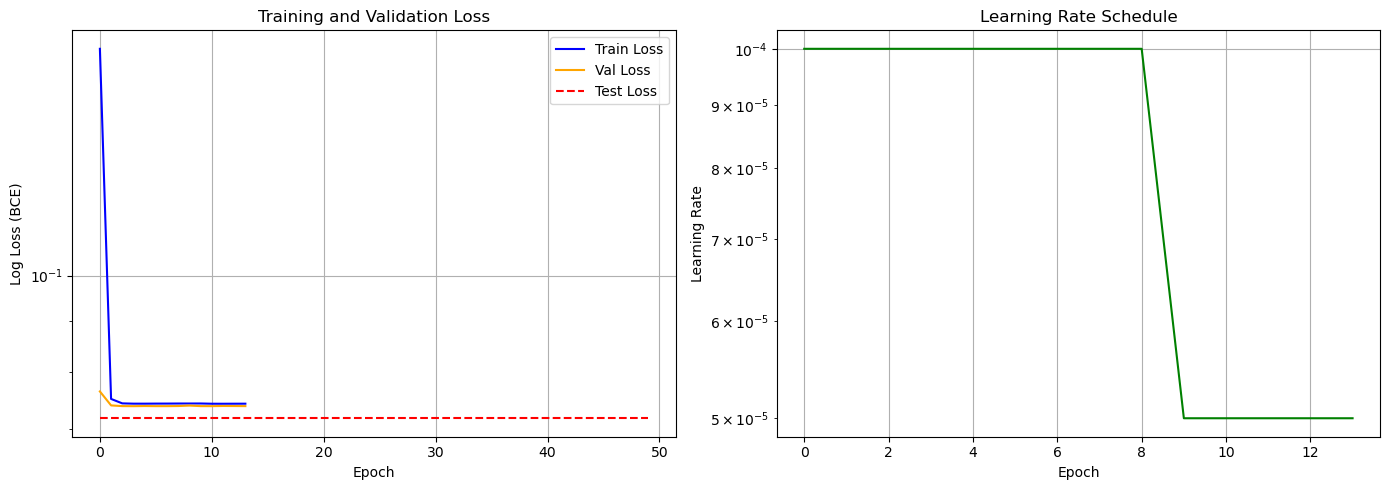

In [95]:
# =====================
# Plot Training History and Test Results
# =====================
if history is not None and len(history.get('train_loss', [])) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].plot(np.arange(NUM_EPOCHS), [test_loss]*NUM_EPOCHS, label='Test Loss', color='red', linestyle="--")

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Log Loss (BCE)')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True)

    # Learning rate
    axes[1].plot(history['lr'], color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_yscale('log')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'training_history.png'), dpi=150)
    plt.show()
else:
    logger.warning("No training history available to plot")

In [117]:
# Loop through oracle patterns and save per-pattern figures for trials 0-19
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

out_base = os.path.join(RUN_DIR, 'oracle_trials_by_pattern')
os.makedirs(out_base, exist_ok=True)

# Get unique pattern info (already defined earlier as unique_trials_info)
unique_trials = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()
oracle_patterns = unique_trials[unique_trials['is_oracle']]['pattern_name'].unique()

logger.info(f"Found {len(oracle_patterns)} oracle patterns")

# Custom colormap for polarity: blue for negative (-1), white for no stim (0), red for positive (+1)
polarity_cmap = ListedColormap(['blue', 'white', 'red'])

# Helper to upsample step-encoded stim (bins -> ms)
def upsample_step_stim(stim_step, input_bin_size=10):
    # stim_step: (n_channels, n_input_bins) integer indices
    return np.repeat(stim_step, input_bin_size, axis=1)

def bin_spike_response(spike_resp, bin_size, truncate_ms):
    """Bin spike responses to specified bin size.
    Args:
        spike_resp: (n_neurons, time_ms) numpy array with binary spike indicators
        bin_size: number of ms per bin
        truncate_ms: total time to consider
    Returns:
        binned_resp: (n_neurons, n_bins) numpy array with spike counts per bin
    """
    spike_resp = spike_resp[:, :truncate_ms]
    n_neurons, n_time = spike_resp.shape
    n_bins = n_time // bin_size
    reshaped = spike_resp[:, :n_bins * bin_size].reshape(n_neurons, n_bins, bin_size)
    binned = reshaped.sum(axis=2).astype(np.float32)
    return binned

def compute_avg_spikes_across_trials(timing_indices, spike_responses_dict, bin_size, truncate_ms):
    """Compute average number of spikes across trials for each neuron in each bin.
    Args:
        timing_indices: list of timing indices for trials to include
        spike_responses_dict: dict mapping timing_idx -> (n_neurons, 2000) spike array
        bin_size: bin size in ms
        truncate_ms: time range to consider
    Returns:
        avg_array: (n_neurons, n_bins) with average spike counts per bin across trials
    """
    if len(timing_indices) == 0:
        # Return zeros
        sample = next(iter(spike_responses_dict.values()))
        n_neurons = sample.shape[0]
        n_bins = truncate_ms // bin_size
        return np.zeros((n_neurons, n_bins), dtype=np.float32)
    
    n_trials = len(timing_indices)
    sample = spike_responses_dict[timing_indices[0]]
    n_neurons = sample.shape[0]
    n_bins = truncate_ms // bin_size
    
    # Accumulate spike counts across all trials
    spike_sum = np.zeros((n_neurons, n_bins), dtype=np.float32)
    
    for timing_idx in timing_indices:
        resp = spike_responses_dict[timing_idx][:, :truncate_ms]
        # Bin the response
        reshaped = resp[:, :n_bins * bin_size].reshape(n_neurons, n_bins, bin_size)
        binned = reshaped.sum(axis=2)  # spike count per bin
        spike_sum += binned.astype(np.float32)
    
    # Compute average
    avg_array = spike_sum / n_trials
    return avg_array

# Process each oracle pattern
for p_idx, pattern_name in enumerate(oracle_patterns):
    pattern_dir = os.path.join(out_base, f"pattern_{pattern_name}")
    os.makedirs(pattern_dir, exist_ok=True)

    # Get all timing indices for this pattern
    timing_list = unique_trials[unique_trials['pattern_name'] == pattern_name]['pattern_timing_index'].tolist()
    timing_list = sorted(timing_list)

    # Load the static pattern subset once
    pattern_subset = pattern_df[pattern_df['pattern_name'] == pattern_name].drop_duplicates(subset=['step_index', 'channel', 'delay_mode'])

    # Get polarity data for this pattern (like cell 8) - extend to TRUNCATE_MS
    polarity_600 = pattern_polarities[pattern_name]  # (n_channels, 600)
    polarity_plot = np.zeros((polarity_600.shape[0], TRUNCATE_MS))
    polarity_plot[:, :600] = polarity_600

    for trial_idx in range(20):  # 0..19
        if trial_idx >= len(timing_list):
            logger.warning(f"Pattern {pattern_name} has only {len(timing_list)} trials; skipping trial {trial_idx}")
            continue
        timing_idx = timing_list[trial_idx]

        # Build stim representation using dataset helper (respects truncate_ms and encoding mode)
        stim_encoded = train_dataset._encode_pattern(pattern_subset, channel_to_index)

        # Actual spike response - BINNED at SPIKE_BIN_SIZE
        actual_response_binned = bin_spike_response(spike_responses[timing_idx], SPIKE_BIN_SIZE, TRUNCATE_MS)

        # Average spikes across other trials in each bin (binned at SPIKE_BIN_SIZE)
        other_trial_indices = [t for t in timing_list if t != timing_idx]
        avg_other_trials = compute_avg_spikes_across_trials(
            other_trial_indices, spike_responses, SPIKE_BIN_SIZE, TRUNCATE_MS
        )

        # Model prediction for this single trial
        if train_dataset.is_categorical:
            model_input = torch.tensor(stim_encoded, dtype=torch.long).unsqueeze(0).to(device)
        elif 'one_hot' in ENCODING_MODE:
            model_input = torch.tensor(stim_encoded, dtype=torch.float32).unsqueeze(0).to(device)
        else:
            model_input = torch.tensor(stim_encoded, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(model_input).cpu().numpy()[0]  # (n_neurons, n_output_bins)

        # Number of output bins
        n_output_bins = TRUNCATE_MS // SPIKE_BIN_SIZE

        # Compute shared vmax for actual and avg other trials (panels 1 and 3)
        shared_vmax = max(actual_response_binned.max(), avg_other_trials.max())
        if shared_vmax == 0:
            shared_vmax = 1

        # Create figure with 4 panels: stim polarity, actual (binned), pred, avg spikes other trials
        fig, axes = plt.subplots(4, 1, figsize=(7, 6), constrained_layout=True)

        # Panel 0: Stimulation pattern colored by polarity (like cell 8) - white background
        im0 = axes[0].imshow(polarity_plot, aspect='auto', cmap=polarity_cmap, vmin=-1, vmax=1, 
                              interpolation='nearest', extent=[0, TRUNCATE_MS, polarity_plot.shape[0], 0])
        axes[0].set_title(f"Pattern {pattern_name} - trial {trial_idx} - stim")
        axes[0].set_ylabel('Channel')
        axes[0].axvline(x=600, color='gray', linestyle='--', linewidth=1, alpha=0.7)

        # Add colorbar for polarity
        cbar0 = fig.colorbar(im0, ax=axes[0], orientation='vertical', shrink=0.8, label='Pulse polarity', ticks=[-1, 0, 1])
        cbar0.ax.set_yticklabels(['Neg (-1)', 'None', 'Pos (+1)'])

        # Panel 1: Actual response (binned at SPIKE_BIN_SIZE) - spike counts
        im1 = axes[1].imshow(actual_response_binned, aspect='auto', cmap='hot', interpolation='nearest', 
                              extent=[0, TRUNCATE_MS, actual_response_binned.shape[0], 0], vmin=0, vmax=shared_vmax)
        axes[1].axvline(x=600, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        axes[1].set_title(f'Actual spike counts ({SPIKE_BIN_SIZE}ms bins)')
        axes[1].set_ylabel('Neuron')

        # Panel 2: Model prediction (at SPIKE_BIN_SIZE resolution)
        im2 = axes[2].imshow(pred, aspect='auto', cmap='hot', interpolation='nearest', 
                              extent=[0, TRUNCATE_MS, pred.shape[0], 0])
        axes[2].axvline(x=600, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        axes[2].set_title(f'Model prediction ({SPIKE_BIN_SIZE}ms bins)')
        axes[2].set_ylabel('Neuron')

        # Panel 3: Average spikes across other 19 trials (binned at SPIKE_BIN_SIZE) - shared scale with panel 1
        im3 = axes[3].imshow(avg_other_trials, aspect='auto', cmap='hot', interpolation='nearest', 
                              extent=[0, TRUNCATE_MS, avg_other_trials.shape[0], 0], vmin=0, vmax=shared_vmax)
        axes[3].axvline(x=600, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        axes[3].set_title(f'Avg spike count over 19 other trials ({SPIKE_BIN_SIZE}ms bins)')
        axes[3].set_ylabel('Neuron')
        axes[3].set_xlabel('Time (ms)')

        # Add shared colorbar for panels 1 and 3 (actual and avg)
        cbar = fig.colorbar(im3, ax=[axes[1], axes[3]], shrink=0.8, label='Spike count')

        # Save figure as compressed JPEG using PIL
        buf = BytesIO()
        plt.savefig(buf, dpi=100, format='png', bbox_inches='tight')
        buf.seek(0)
        img = Image.open(buf).convert('RGB')
        fig_path = os.path.join(pattern_dir, f"trial_{trial_idx:02d}_timing_{timing_idx}.jpg")
        img.save(fig_path, format='JPEG', quality=70, optimize=True)
        buf.close()
        plt.close(fig)

        logger.info(f"Saved pattern {pattern_name} trial {trial_idx} figure to {fig_path}")

# Done
logger.info(f"Saved all oracle pattern figures to {out_base}")

2026-01-29 10:45:46,641 - INFO - Found 50 oracle patterns
2026-01-29 10:45:46,971 - INFO - Saved pattern 4033 trial 0 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_00_timing_0.jpg
2026-01-29 10:45:47,271 - INFO - Saved pattern 4033 trial 1 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_01_timing_355.jpg
2026-01-29 10:45:47,573 - INFO - Saved pattern 4033 trial 2 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_02_timing_457.jpg
2026-01-29 10:45:47,944 - INFO - Saved pattern 4033 trial 3 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_03_timing_638.jpg
2026-01-29 10:45:48,229 - INFO - Saved pattern 4033 trial 4 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_04_timing_1132.jpg
2026-01-29 10:45:48,521 - INFO - Saved pattern 4033 trial 5 figure to results/2026-01-28_13-21-19/oracle_trials_by_pattern/pattern_4033/trial_0